# Perfectly Vertical Grating Coupler (PVGC) Inverse Design
Inverse design not available in free tier. 

## Geometry

running luminescent python frontenda


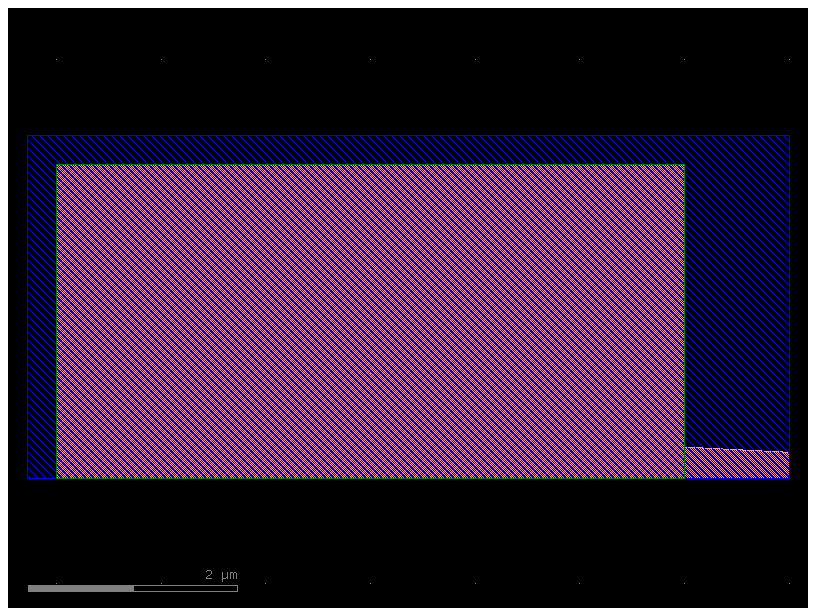

In [1]:
import os
import numpy as np
import luminescent as lm
import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import matplotlib.pyplot as plt

wideband = False
bidirectional = False

if wideband and bidirectional:
    study="wbPVGC" # wideband bidirectional
elif bidirectional:
    study="bPVGC" # bidirectional
else:
    study="PVGC"

# folder for saving config and results
path = os.path.join("runs", study)

wavelength=1.55
if wideband:
    bandwidth=.07
else:
    bandwidth = 0.005
wavelengths = np.linspace(wavelength-bandwidth/2, wavelength+bandwidth/2, 5)

materials = lm.MATERIAL_LIBRARY

material_core='Si'
material_clad = "SiO2"
n_core=materials[material_core]['n']
n_clad=materials[material_clad]['n']
λ_core = wavelength/n_core
λ_clad = wavelength/n_clad

materials["background"] = materials[material_clad]  # set background material
materials["design"] = lm.PlaceholderMaterial(n_core)

w = 10.4  # gaussian beam waist
w=4
r= w / 2  # source gaussian radius
R=1.5*r

if bidirectional:
    w_design =1*R  # of design region
    l_design =1.5 *R # of design region
else:
    w_design =1*R  # of design region
    l_design =2*R # of design region

w_wg = 0.5
l_wg = 2 * w_wg
h_wg = 0.22
d_etch = 0.07
h_slab = h_wg - d_etch

# margins
lateral_port_margin = height_port_margin = 1*h_wg
margin = 1.25 * lateral_port_margin
zmargin = 1.25 * height_port_margin

nres = 4  # number of grid points per wavelength in material (not vacuum)

dz=λ_clad/ nres
source_offset = 2*dz

gap1=zmargin
gap2=1/4*λ_clad
z_port = h_wg+gap1
zmin=-gap2
zmax=z_port+source_offset

WG = 1, 0
BBOX = 10, 0
DESIGN = 500, 0

# makes gdsfadory component to be optimized. has rectangular design region with port stubs. ports numbered clockwise from bottom left.
c = gf.Component()
taper=.1
design = c << lm.mimo(
    l_design,
    w_design,
    east=[w_design-w_wg/4],
    w_wg=w_wg/2,
    l_wg=l_wg,
    layer_wg=WG,
    layer_design=DESIGN,
    taper=[(0, taper/2)],
    init=1,
)

source_=f'o1'

if bidirectional:
    c << gf.components.bbox(component=c, layer=BBOX, top=margin)
else:
    design.movex(-R)
    c << gf.components.bbox(component=c, layer=BBOX, top=margin,left=margin,)

c.add_port(f'o2', port=design.ports[f'o1'])
# additional ports not attached to gdsfactory component
ports = [
    lm.Monitor(
        name=source_,
        origin=[0, 0, z_port],
        frame=[[1, 0, 0], [0, 1, 0], [0, 0, 1]],
    )
]
c.plot()

## Solve

saving mode plots to /home/weihu/moon/luminescent/runs/PVGC/modes/1
polyeps: [(<POLYGON ((-0.125 0.22, 0.125 0.22, 0.125 0, -0.125 0, -0.125 0.22))>, 12.082576, 'wg'), (<POLYGON ((0.345 -0.22, 0.345 0.44, -0.125 0.44, -0.125 -0.22, 0.345 -0.22))>, 2.085136, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 000A


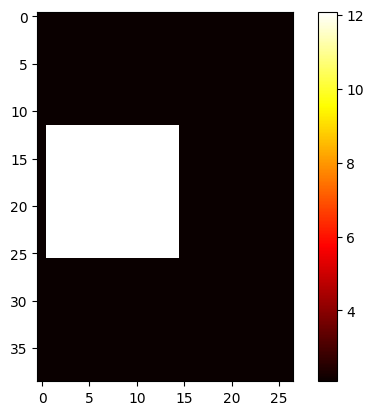

/home/weihu/moon/luminescent/runs/PVGC/modes/1/1.55 mode 0 (neff=1.997+0.000j)


saving mode plots to /home/weihu/moon/luminescent/runs/PVGC/modes/2
using simulation folder /home/weihu/moon/luminescent/runs/PVGC


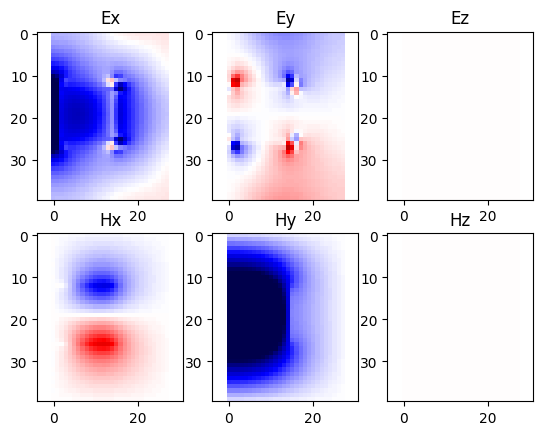

In [2]:
# layer stack. lower mesh order layers override higher mesh order layers. for 2.5D problems as is here, the mesher will slice thru middle of 'core' layer
layers = {
    "wg": LayerLevel(
        layer=LogicalLayer(layer=WG),
        zmin=0,
        thickness=h_wg,
        material='Si',
        mesh_order=100,
    ),
    "design": LayerLevel(
        layer=LogicalLayer(layer=DESIGN),
        zmin=h_slab,
        thickness= d_etch,
        material="design",
        mesh_order=1,
    ),
}
layer_stack = LayerStack(layers=layers)

_dx = λ_clad / nres
nr = round(R/_dx)
_dx=R/nr

if bidirectional:
    x =y= np.linspace(_dx/2,R-_dx/2, nr)
else:
    x = np.linspace(-R+_dx/2,R-_dx/2,2*nr)
    y = np.linspace(_dx/2,R-_dx/2, nr)
X, Y = np.meshgrid(x, y, indexing='ij')
g = np.exp(-(X**2 + Y**2) / (2 * (w/2) ** 2))

wg_mode=lm.Sensor(
        ports=['o2'],
        start=[-w_wg/4, -height_port_margin],
        stop=[w_wg / 4+lateral_port_margin, h_wg + height_port_margin],
        boundaries=[('PEC','PML'),'PML']
    )
if bidirectional:
    source_mode=lm.Sensor(
        ports=[source_],
         fields={
            "Ey": g,
            "Hx": -g * n_clad,
        },
        start=[0, 0],
        stop=[R,R],
        boundaries=[('PMC','PML'),('PEC','PML')]
    )
else:
    source_mode=lm.Sensor(
        ports=[source_],
        fields={
            "Ey": g,
            "Hx": -g * n_clad,
        },
        start=[-R, 0],
        stop=[R,R],
        boundaries=['PML',('PEC','PML')]
    )
modes = [wg_mode, source_mode]

sources = [
    lm.Source(
        source_,
        wavelength=wavelength,
        bandwidth=wavelength / 5,
        source_offset=source_offset,
    )
]

targets =        [
            lm.Target(
                key=f"To2@0,{source_}@0",
                target=1,
                weight=1 / len(wavelengths),
                wavelength=wl,
                func="relu-",
            )
            for wl in wavelengths        ]

tmax = 1.3 *(
    ( 6*(h_wg*n_core+gap2*n_clad)+(source_offset+gap1)*n_clad) 
    + (l_wg +l_design + w_design+R)* n_core
) / wavelength

lmin_design = 0.065
designs = [
    lm.Design(
        "design",
        layer=DESIGN,
        lmin=lmin_design,
        fill_material='Si',
        void_material='SiO2',
        repdims="z",
    ),
]

optimizer = lm.Optimizer(
    stoploss=0.1,
    # lowloss=0.4,
    iters=30,  # max iters
    momentum=0.8,
    # contrast=1.0,
)

boundaries = ['PML', ['PEC',"PML"], ["PEC", "PML"]]
PML_decay = [.7, 0.3, 0.7]  # relative PML thicknesses in x, y, z

labels={
    # 'o1':'λ = 1311nm',
}

if bidirectional:
    mirrors=['x-','y-']
else:
    mirrors=['y-']
views = [
    lm.View("Ey",y=0, z=d_etch / 2 + h_slab,mirrors=mirrors,show_box=False,material_color_intensity=5),
]

relative_courant = 0.95
frame_every = 25  # save frame every `frame_every` periods for movie

lm.setup(
    #
    path=path,  # path to make problem folder
    component=c,
    wavelength=wavelength,
    wavelengths=wavelengths,
    ports=ports,
    modes=modes,
    sources=sources,
    boundaries=boundaries,
    #
    materials=materials,
    layer_stack=layer_stack,
    #
    zmin=zmin,  # zmin of simulation region
    zmax=zmax,  # zmax of simulation region
    #
    nres=nres,
    tmax=tmax,  # total simulation time in periods
    PML_decay=PML_decay,
    relative_courant=relative_courant,
    frame_every=frame_every,
    #
    views=views,
    # inverse design parameters
    # load_designs=True,
    designs=designs,
    targets=targets,
    optimizer=optimizer,
)

In [3]:
# nres=6
# frame_every=1
# wavelengths=np.linspace(1.5,1.6,101)
# tmax=40
# path0=path
# path=path0+'_final'
# os.system(f'cp -r {path0}/designs/ {path}')
# lm.setup(
#     #
#     path=path,  # path to make problem folder
#     component=c,
#     wavelength=wavelength,
#     wavelengths=wavelengths,
#     ports=ports,
#     modes=modes,
#     sources=sources,
#     boundaries=boundaries,
#     #
#     materials=materials,
#     layer_stack=layer_stack,
#     #
#     zmin=zmin,  # zmin of simulation region
#     zmax=zmax,  # zmax of simulation region
#     #
#     nres=nres,
#     tmax=tmax,  # total simulation time in periods
#     PML_decay=PML_decay,
#     relative_courant=relative_courant,
#     frame_every=frame_every,
#     #
#     views=views,
#     # inverse design parameters
#     load_designs=True,
#     designs=designs,
# )
# raise SystemExit

Video generated successfully at /home/weihu/moon/luminescent/runs/PVGC/simulation.gif!


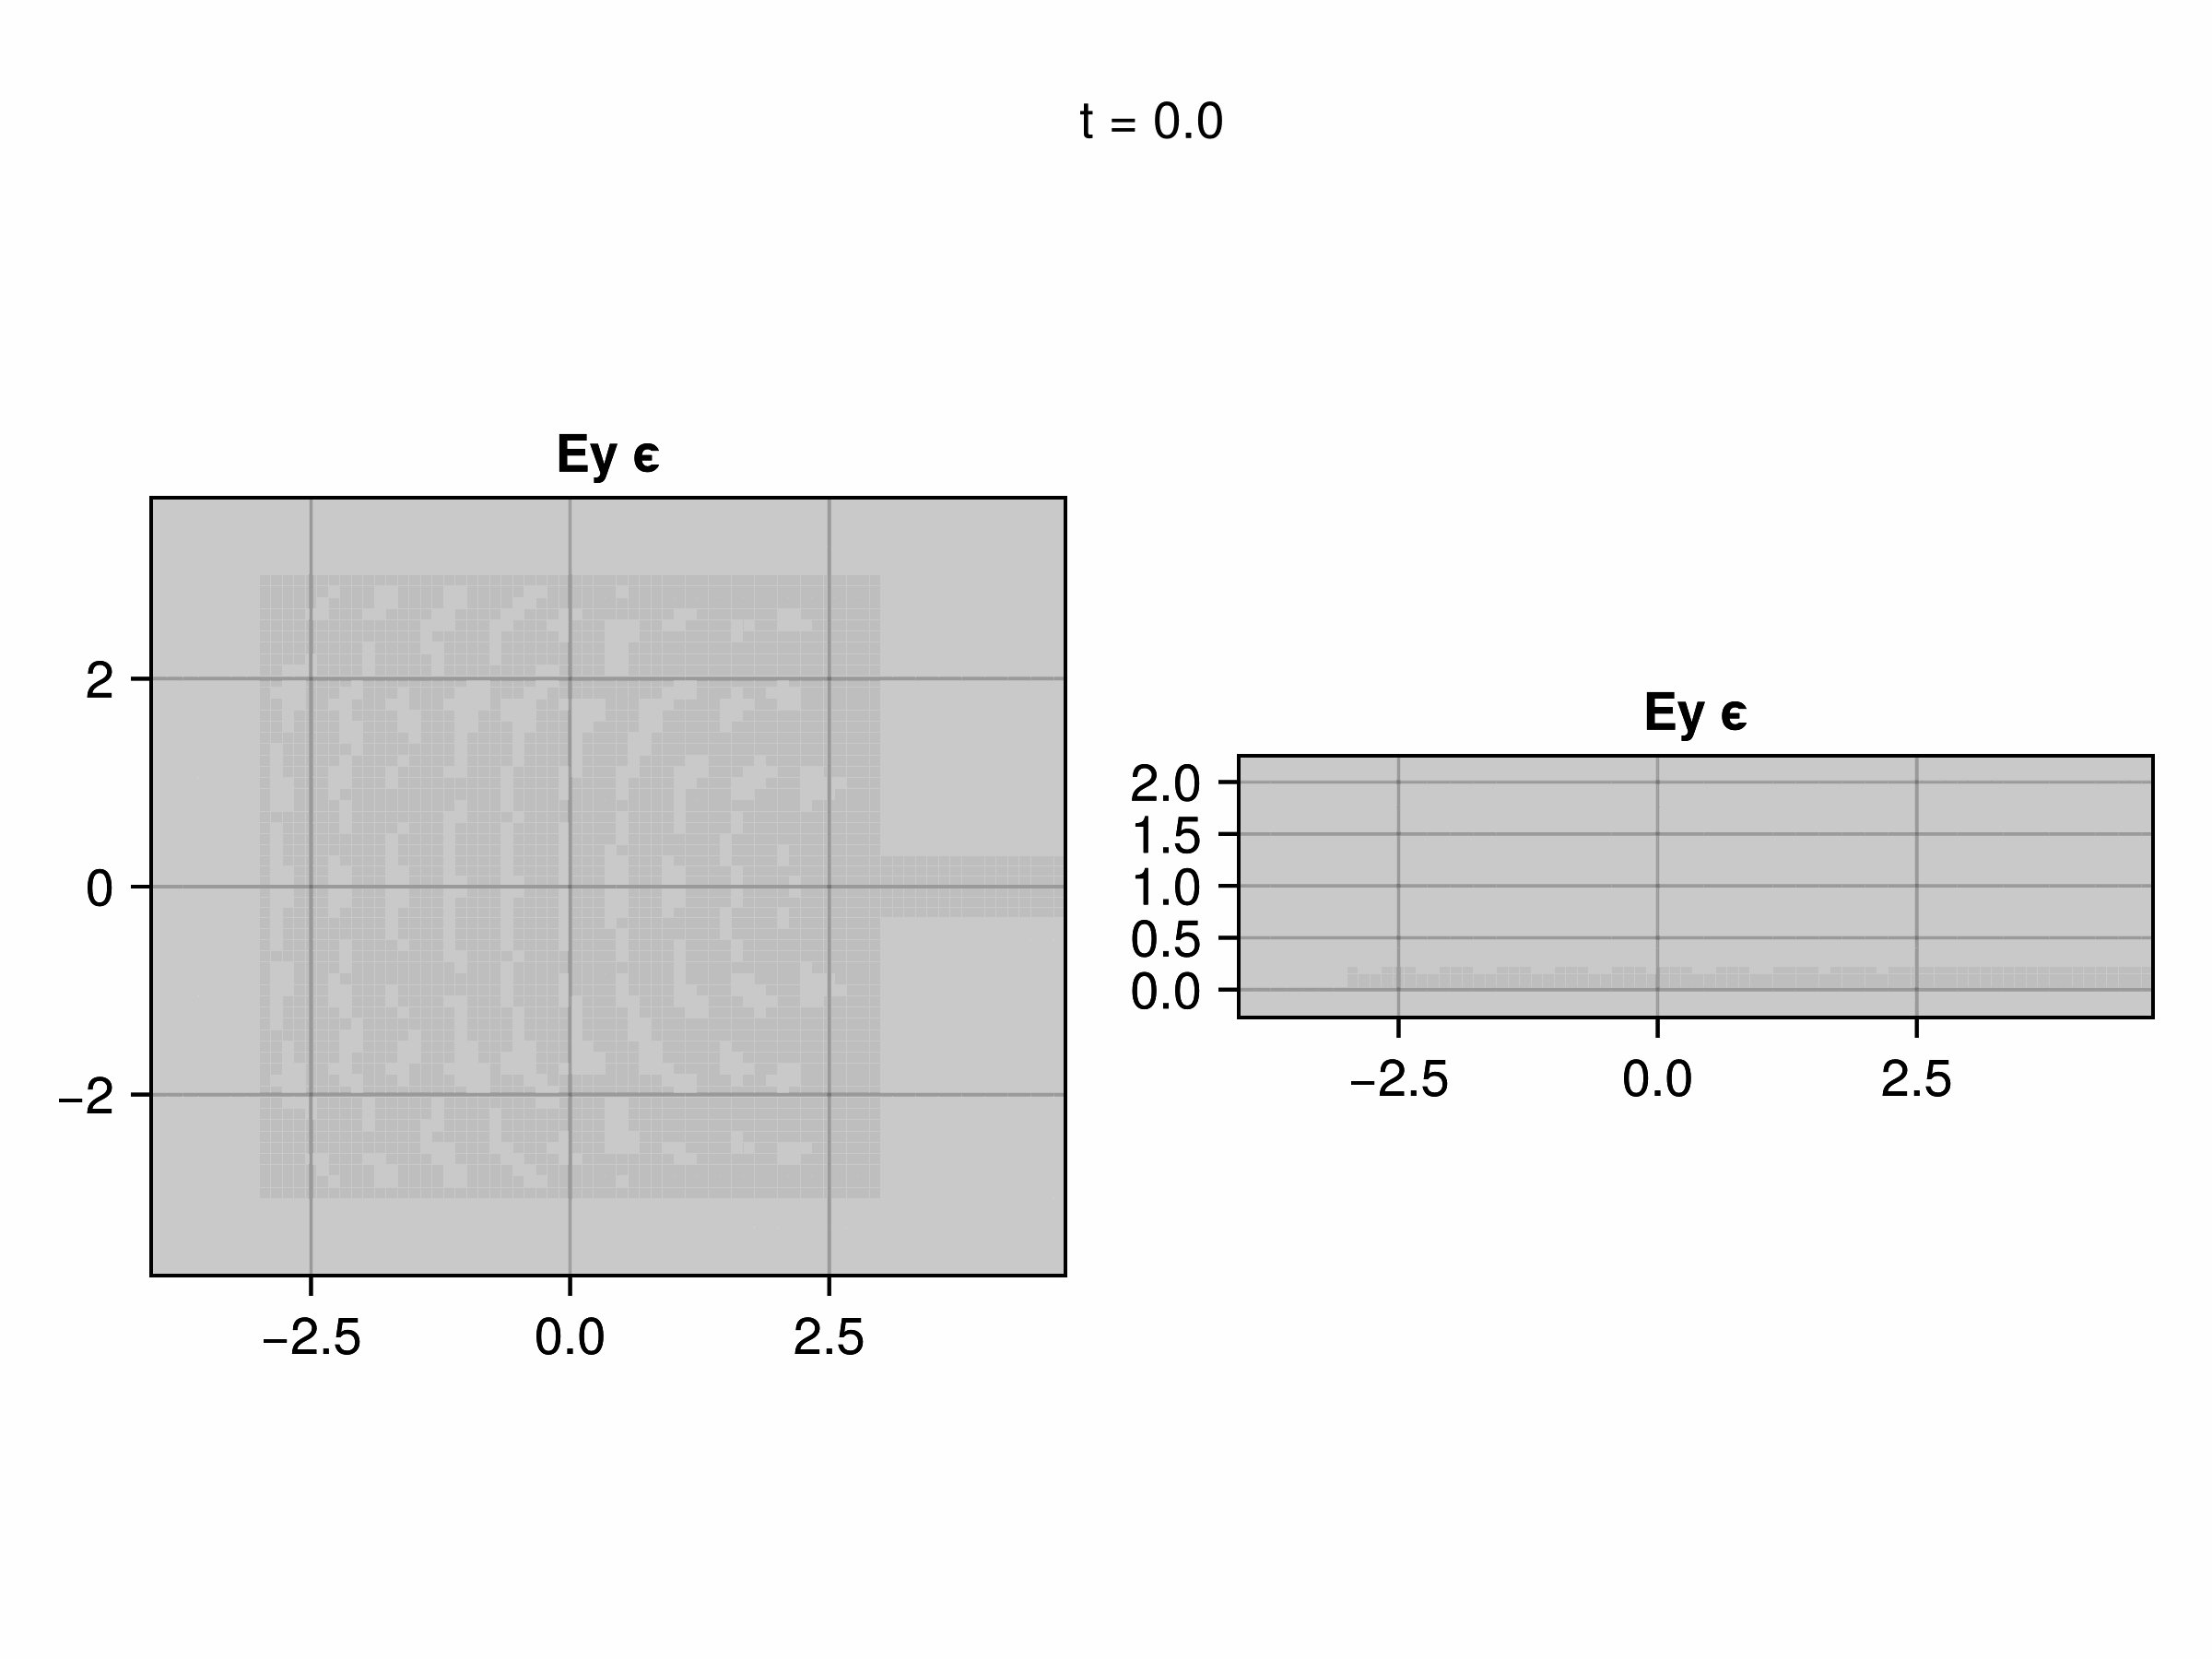

In [6]:
lm.movie(path,views,1)#,run=False)

In [5]:
plt.close()
sol = lm.load(path)
x = wavelengths

y = lm.query(sol, "To2@0,o1@0")  # wavelength or frequency ordered depending on problem setup
y=[10*np.log10(y) for y in y]

plt.plot(x, y)
plt.xlabel("wavelength [um]")
plt.ylabel("S21 [dB]")
plt.show()

loading solution from /home/weihu/moon/luminescent/runs/PVGC
may take a minute if simulation folder is remotely mounted


FileNotFoundError: [Errno 2] No such file or directory: '/home/weihu/moon/luminescent/runs/PVGC/.solution.json.tar'